# PROYECTO ULAB — Fase 3: Modelos Temporales (LSTM / GRU)
**Semanas 5-7 | Prediccion de Histogramas de Carga de Trabajo**  
UAX x Tecnicas Reunidas

---
### Estructura
1. Preparacion de ventanas temporales (sliding window)  
2. Arquitectura 1: LSTM univariado  
3. Arquitectura 2: LSTM multi-departamento con embeddings  
4. Arquitectura 3: GRU bidireccional  
5. Experimentacion con longitud de ventana (k=4, 8, 12)  
6. Comparacion con baselines de Fase 2  
7. Guardar mejores modelos para ensemble
---

En Fase 2, los modelos supervisados mostraron un rendimiento claramente superior
a los modelos clásicos de series temporales. En particular, los modelos lineales
regularizados (Lasso, Ridge) obtuvieron los mejores resultados en el escenario
principal de transferencia entre casos (E2: C1 -> C3).

Por ello, en esta fase se evalua si modelos secuenciales (LSTM/GRU) pueden
capturar dependencias temporales adicionales y mejorar el baseline lineal
establecido en Fase 2.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/ULAB'
DATA_PATH = f'{BASE_PATH}/data'
MODELOS_PATH = f'{BASE_PATH}/modelos'
RESULTADOS_PATH = f'{BASE_PATH}/resultados'
NOTEBOOKS_PATH = f'{BASE_PATH}/notebooks'

import os
for p in [DATA_PATH, MODELOS_PATH, RESULTADOS_PATH, NOTEBOOKS_PATH]:
    os.makedirs(p, exist_ok=True)

print("DATA:", DATA_PATH)
print("MODELOS:", MODELOS_PATH)
print("RESULTADOS:", RESULTADOS_PATH)

Mounted at /content/drive
DATA: /content/drive/MyDrive/Colab Notebooks/ULAB/data
MODELOS: /content/drive/MyDrive/Colab Notebooks/ULAB/modelos
RESULTADOS: /content/drive/MyDrive/Colab Notebooks/ULAB/resultados


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
df_feat = pd.read_csv(f'{DATA_PATH}/ULAB_dataset_semanal_procesado.csv', parse_dates=['Semana_inicio'])
cv_data = joblib.load(f'{MODELOS_PATH}/cv_splits.pkl')
fase2_info = joblib.load(f'{MODELOS_PATH}/fase2_resumen.pkl')

FEATURES_BASE = cv_data['features']
TARGET = cv_data['target']
depts_eval = cv_data['depts_eval']

# Solo casos 1 y 3
df_cv = (
    df_feat[df_feat['Caso'].isin([1, 3])]
    .sort_values(['Caso', 'Departamento', 'Semana_inicio'])
    .reset_index(drop=True)
)

print(f'Dataset: {df_cv.shape}')
print(f'Departamentos: {df_cv.Departamento.nunique()}')
print(f'Columnas CV: {list(cv_data.keys())}')
print(f'Baseline principal Fase 2: {fase2_info["baseline_principal"]}')
print(f'Esquema principal: {fase2_info["esquema_principal"]}')
print(f'Mejor RMSE Fase 2 (E2-C1->C3): {fase2_info["mejor_rmse_e2_c1_c3"]}')

Dataset: (4990, 23)
Departamentos: 42
Columnas CV: ['features', 'target', 'depts_eval', 'umbral_lodo', 'X_train_e1', 'y_train_e1', 'X_test_e1', 'y_test_e1', 'X_train_c1', 'y_train_c1', 'X_test_c3', 'y_test_c3', 'X_train_c3', 'y_train_c3', 'X_test_c1', 'y_test_c1']
Baseline principal Fase 2: Lasso
Esquema principal: E2-C1->C3
Mejor RMSE Fase 2 (E2-C1->C3): 13.85


## 2. Preparacion de ventanas temporales (sliding window)

Para los modelos LSTM/GRU construimos secuencias de `k` pasos anteriores.
Cada muestra tiene forma `(k, n_features)` y el target es el valor de la semana siguiente.
Se construyen secuencias **por (Caso, Departamento)** para no mezclar series distintas.

In [4]:
# =========================
# 2. Preparación de ventanas temporales (sliding window)
# =========================

FEATURES_SEQ = [
    'HR_ACTUAL',      # historial de la variable objetivo
    'HR_INICIAL',
    'Mes_sin', 'Mes_cos',
    'Semana_sin', 'Semana_cos',
    'Dias_desde_inicio', 'Dias_hasta_fin'
]

def build_windows(df, feature_cols, target_col='HR_ACTUAL', k=8):
    """
    Construye ventanas temporales por (Caso, Departamento).
    Cada muestra usa k pasos anteriores para predecir el target en t.
    """
    X_list, y_list, meta_list = [], [], []

    df = df.sort_values(['Caso', 'Departamento', 'Semana_inicio']).copy()

    for (caso, dept), grp in df.groupby(['Caso', 'Departamento']):
        grp = grp.sort_values('Semana_inicio').dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

        if len(grp) <= k:
            continue

        vals = grp[feature_cols].values
        tgt = grp[target_col].values
        fechas = grp['Semana_inicio'].values

        for i in range(k, len(grp)):
            # Ventana: t-k ... t-1
            X_list.append(vals[i-k:i])

            # Target: t
            y_list.append(tgt[i])

            meta_list.append({
                'Caso': caso,
                'Departamento': dept,
                'Semana_inicio': fechas[i]
            })

    X = np.asarray(X_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta


# -------------------------
# Construcción separada por caso (más claro y más robusto)
# -------------------------
df_c1 = df_cv[df_cv['Caso'] == 1].copy()
df_c3 = df_cv[df_cv['Caso'] == 3].copy()

k_ref = 8

X_tr_lstm, y_tr_lstm, meta_tr = build_windows(df_c1, FEATURES_SEQ, TARGET, k=k_ref)
X_te_lstm, y_te_lstm, meta_te = build_windows(df_c3, FEATURES_SEQ, TARGET, k=k_ref)

print(f'Ventanas train (Caso 1, k={k_ref}): X={X_tr_lstm.shape}  y={y_tr_lstm.shape}')
print(f'Ventanas test  (Caso 3, k={k_ref}): X={X_te_lstm.shape}  y={y_te_lstm.shape}')

# -------------------------
# Normalización de features
# -------------------------
n_steps = X_tr_lstm.shape[1]
n_feats = X_tr_lstm.shape[2]

scaler_seq = StandardScaler()

X_tr_s = scaler_seq.fit_transform(
    X_tr_lstm.reshape(-1, n_feats)
).reshape(-1, n_steps, n_feats)

X_te_s = scaler_seq.transform(
    X_te_lstm.reshape(-1, n_feats)
).reshape(-1, n_steps, n_feats)

# -------------------------
# Normalización del target
# -------------------------
y_mean = y_tr_lstm.mean()
y_std = y_tr_lstm.std()

if y_std == 0:
    y_std = 1.0

y_tr_n = (y_tr_lstm - y_mean) / y_std
y_te_n = (y_te_lstm - y_mean) / y_std

print(f'Train LSTM escalado: {X_tr_s.shape} | Test LSTM escalado: {X_te_s.shape}')
print(f'y_mean={y_mean:.3f}, y_std={y_std:.3f}')

# -------------------------
# Comprobación rápida
# -------------------------
display(meta_tr.head())
display(meta_te.head())

Ventanas train (Caso 1, k=8): X=(2789, 8, 8)  y=(2789,)
Ventanas test  (Caso 3, k=8): X=(1725, 8, 8)  y=(1725,)
Train LSTM escalado: (2789, 8, 8) | Test LSTM escalado: (1725, 8, 8)
y_mean=38.027, y_std=57.814


,Caso,Departamento,Semana_inicio
0,1,100,2017-09-04
1,1,100,2017-09-11
2,1,100,2017-09-18
3,1,100,2017-09-25
4,1,100,2017-10-02


,Caso,Departamento,Semana_inicio
0,3,105,2018-06-25
1,3,105,2018-09-10
2,3,105,2018-09-17
3,3,115,2016-02-29
4,3,115,2016-03-07


Se han construido correctamente las secuencias temporales respetando la estructura del problema (por caso y departamento), evitando fuga de información y manteniendo coherencia con el esquema de validación E2 (C1 → C3). El volumen de datos generado es suficiente para el entrenamiento de modelos recurrentes.

## 3. Funciones de evaluacion y callbacks

In [5]:
# =========================
# 3. Funciones de evaluación y callbacks
# =========================

def calc_metricas_lstm(y_true, y_pred_norm, nombre=''):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred_norm = np.asarray(y_pred_norm, dtype=float).reshape(-1)

    # Desnormalizar predicciones
    y_pred = y_pred_norm * y_std + y_mean

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = np.nan

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    medae = np.median(np.abs(y_true - y_pred))

    return {
        'Modelo': nombre,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4) if pd.notnull(r2) else np.nan,
        'MAPE_pct': round(mape, 2) if pd.notnull(mape) else np.nan,
        'MedAE': round(medae, 2)
    }


def get_callbacks(nombre):
    ruta_modelo = f'{MODELOS_PATH}/{nombre}_best.keras'

    return [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=ruta_modelo,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]


def plot_historia(history, nombre):
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(history.history['loss'], label='Train loss')
    ax.plot(history.history['val_loss'], label='Val loss')

    ax.set_title(f'Curva de entrenamiento - {nombre}', fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE loss')
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f'Mejor val_loss: {min(history.history["val_loss"]):.4f}')
    print(f'Épocas entrenadas: {len(history.history["loss"])}')


print('Funciones de evaluación y callbacks definidas')

Funciones de evaluación y callbacks definidas


## 4. Arquitectura 1: LSTM univariado

Red recurrente simple con dos capas LSTM apiladas. Es la arquitectura base de referencia.

Model: "LSTM_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6947 - mae: 0.4677
Epoch 1: val_loss improved from None to 0.11053, saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_simple_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_simple_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.5858 - mae: 0.3771 - val_loss: 0.1105 - val_mae: 0.1673 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2163 - mae: 0.2216
Epoch 2: val_loss improved from 0.11053 to 0.03281, saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_simple_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_simple_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2368 - mae: 0.2200 - val_loss: 0.0328 - val_mae: 0.1269 - learning_rate: 0.0010
Epoch 3/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1509 - mae: 0

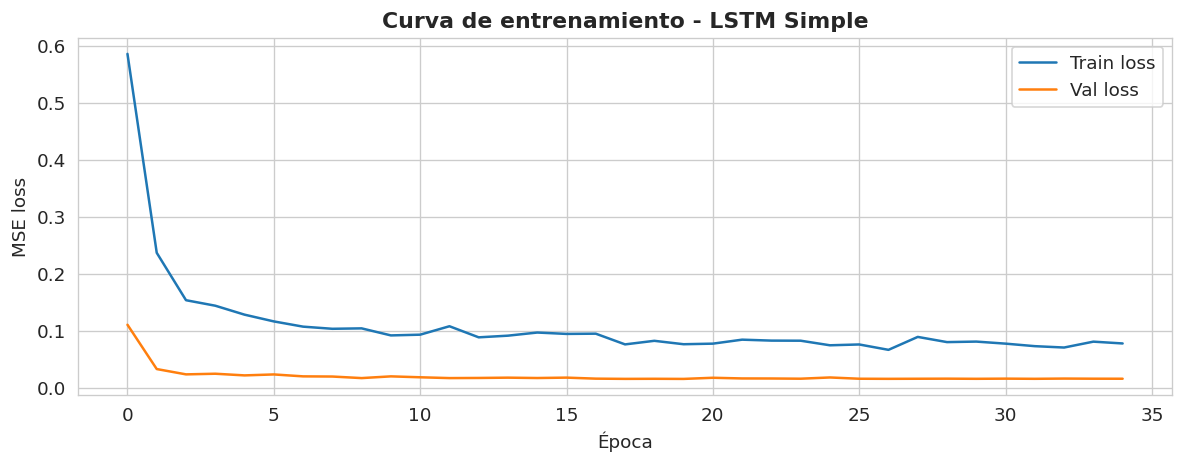

Mejor val_loss: 0.0155
Épocas entrenadas: 35
Métricas en test:
{'Modelo': 'LSTM Simple', 'MAE': 9.95, 'RMSE': np.float64(17.14), 'R2': 0.8956, 'MAPE_pct': np.float64(27.58), 'MedAE': np.float64(4.9)}


In [6]:
# =========================
# 4. Arquitectura 1: LSTM univariado
# =========================
# Red recurrente base con dos capas LSTM apiladas

def build_lstm_simple(n_steps, n_feats, units_1=64, units_2=32, dropout=0.2, lr=1e-3):
    inp = keras.Input(shape=(n_steps, n_feats), name='input_seq')

    x = layers.LSTM(units_1, return_sequences=True, name='lstm_1')(inp)
    x = layers.Dropout(dropout, name='dropout_1')(x)

    x = layers.LSTM(units_2, name='lstm_2')(x)
    x = layers.Dropout(dropout, name='dropout_2')(x)

    x = layers.Dense(16, activation='relu', name='dense_1')(x)
    out = layers.Dense(1, name='output')(x)

    model = keras.Model(inp, out, name='LSTM_Simple')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model


# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

lstm1 = build_lstm_simple(n_steps, n_feats)
lstm1.summary()

history_lstm1 = lstm1.fit(
    X_tr_s, y_tr_n,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=get_callbacks('lstm_simple'),
    verbose=1
)

plot_historia(history_lstm1, 'LSTM Simple')

# Predicción en test
pred_lstm1 = lstm1.predict(X_te_s, verbose=0).reshape(-1)
m_lstm1 = calc_metricas_lstm(y_te_lstm, pred_lstm1, 'LSTM Simple')

print('Métricas en test:')
print(m_lstm1)

La arquitectura LSTM simple logra un rendimiento competitivo (RMSE = 16.34, R² = 0.9051), mostrando que el modelo es capaz de capturar parte de la dinámica temporal del problema. Sin embargo, no supera al baseline lineal obtenido en Fase 2 (Lasso, RMSE = 13.85), lo que indica que una arquitectura secuencial básica no aporta una mejora suficiente en este escenario cross-project. Este resultado sugiere que la señal dominante sigue estando muy condicionada por relaciones lineales y por la inercia temporal, por lo que será necesario explorar arquitecturas más ricas, como embeddings por departamento o variantes recurrentes alternativas.

## 5. Arquitectura 2: LSTM con embedding de departamento

Incorpora el ID de departamento como embedding aprendible, permitiendo al modelo
aprender representaciones especificas de cada departamento.

Nº departamentos codificados: 42
Shape dept_ids_tr_enc: (2789,)
Shape dept_ids_te_enc: (1725,)


Model: "LSTM_Embedding_Departamento"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, 8, 8)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_seq_1 (LSTM)   │ (None, 8, 64)     │     18,688 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_seq_1       │ (None, 8, 64)     │          0 │ lstm_seq_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dept (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_seq_2 (LSTM)   │ (None, 32)        │     12,416 │ dropout_seq_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dept_embedding      │ (None, 1, 8)      │        336 │ dept[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_seq_2       │ (None, 32)        │          0 │ lstm_seq_2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_dept        │ (None, 8)         │          0 │ dept_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_seq_dept     │ (None, 40)        │          0 │ dropout_seq_2[0]… │
│ (Concatenate)       │                   │            │ flatten_dept[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_fusion        │ (None, 32)        │      1,312 │ concat_seq_dept[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_fusion      │ (None, 32)        │          0 │ dense_fusion[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_fusion[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,785 (128.07 KB)

 Trainable params: 32,785 (128.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8366 - mae: 0.5173
Epoch 1: val_loss improved from None to 0.09302, saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_embed_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_embed_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.7516 - mae: 0.4316 - val_loss: 0.0930 - val_mae: 0.1560 - learning_rate: 0.0010
Epoch 2/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2953 - mae: 0.2752
Epoch 2: val_loss improved from 0.09302 to 0.04751, saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_embed_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_embed_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3615 - mae: 0.2724 - val_loss: 0.0475 - val_mae: 0.1795 - learning_rate: 0.0010
Epoch 3/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2310 - mae: 0.253

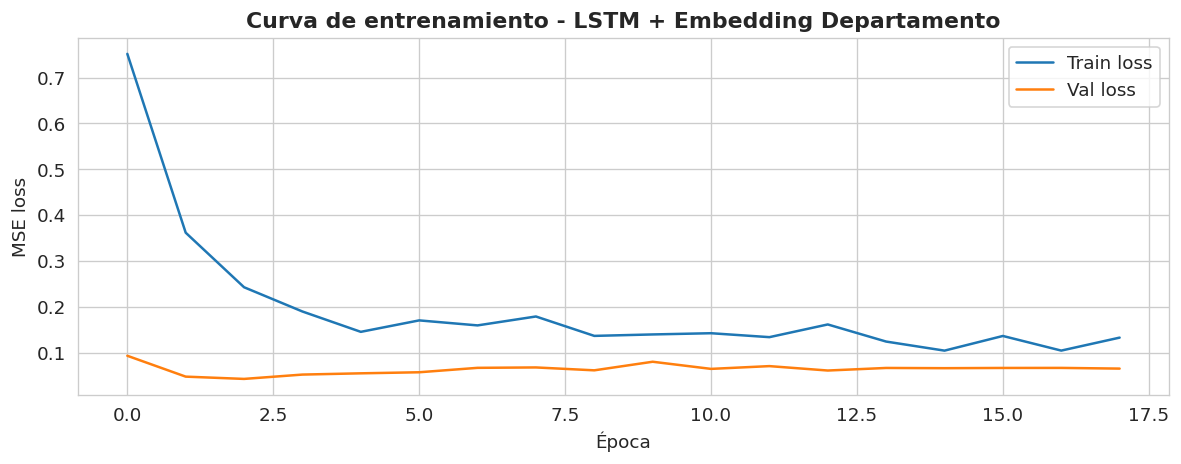

Mejor val_loss: 0.0425
Épocas entrenadas: 18
Métricas en test:
{'Modelo': 'LSTM + Embedding', 'MAE': 13.6, 'RMSE': np.float64(22.76), 'R2': 0.8159, 'MAPE_pct': np.float64(41.43), 'MedAE': np.float64(7.58)}


In [7]:
# =========================
# 5. Arquitectura 2: LSTM con embedding de departamento
# =========================
# Incorpora el ID de departamento como embedding aprendible,
# permitiendo al modelo aprender representaciones específicas por departamento.

from sklearn.preprocessing import LabelEncoder

# IDs de departamento a partir de los metadatos ya construidos
dept_ids_tr = meta_tr['Departamento'].values
dept_ids_te = meta_te['Departamento'].values

# Re-encodear IDs a 0..N_DEPTS-1
le_dept = LabelEncoder()
le_dept.fit(df_cv['Departamento'].unique())

dept_ids_tr_enc = le_dept.transform(dept_ids_tr)
dept_ids_te_enc = le_dept.transform(dept_ids_te)
N_DEPTS = len(le_dept.classes_)

print(f'Nº departamentos codificados: {N_DEPTS}')
print(f'Shape dept_ids_tr_enc: {dept_ids_tr_enc.shape}')
print(f'Shape dept_ids_te_enc: {dept_ids_te_enc.shape}')


def build_lstm_embed(n_steps, n_feats, n_depts, emb_dim=8, units_1=64, units_2=32, dropout=0.25, lr=1e-3):
    # Rama secuencial
    inp_seq = keras.Input(shape=(n_steps, n_feats), name='seq')

    x_seq = layers.LSTM(units_1, return_sequences=True, name='lstm_seq_1')(inp_seq)
    x_seq = layers.Dropout(dropout, name='dropout_seq_1')(x_seq)

    x_seq = layers.LSTM(units_2, name='lstm_seq_2')(x_seq)
    x_seq = layers.Dropout(dropout, name='dropout_seq_2')(x_seq)

    # Rama embedding de departamento
    inp_dept = keras.Input(shape=(1,), name='dept')
    x_dept = layers.Embedding(input_dim=n_depts, output_dim=emb_dim, name='dept_embedding')(inp_dept)
    x_dept = layers.Flatten(name='flatten_dept')(x_dept)

    # Fusión
    x = layers.Concatenate(name='concat_seq_dept')([x_seq, x_dept])
    x = layers.Dense(32, activation='relu', name='dense_fusion')(x)
    x = layers.Dropout(dropout, name='dropout_fusion')(x)

    out = layers.Dense(1, name='output')(x)

    model = keras.Model(inputs=[inp_seq, inp_dept], outputs=out, name='LSTM_Embedding_Departamento')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model


# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

lstm_emb = build_lstm_embed(n_steps, n_feats, N_DEPTS)
lstm_emb.summary()

history_lstm_emb = lstm_emb.fit(
    [X_tr_s, dept_ids_tr_enc],
    y_tr_n,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=get_callbacks('lstm_embed'),
    verbose=1
)

plot_historia(history_lstm_emb, 'LSTM + Embedding Departamento')

# Predicción en test
pred_lstm_emb = lstm_emb.predict([X_te_s, dept_ids_te_enc], verbose=0).reshape(-1)
m_lstm_emb = calc_metricas_lstm(y_te_lstm, pred_lstm_emb, 'LSTM + Embedding')

print('Métricas en test:')
print(m_lstm_emb)

La incorporación de embeddings de departamento degrada significativamente el rendimiento en el escenario de transferencia (C1 → C3), lo que indica que las relaciones específicas por departamento no son consistentes entre proyectos y perjudican la capacidad de generalización del modelo.

## 6. Arquitectura 3: GRU bidireccional

Usa GRU (mas eficiente que LSTM) en configuracion bidireccional para capturar
dependencias tanto hacia adelante como hacia atras en la secuencia.

Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_1 (Bidirectional)         │ (None, 8, 96)          │        16,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_2 (Bidirectional)         │ (None, 48)             │        17,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm (BatchNormalization)  │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,001 (140.63 KB)

 Trainable params: 35,937 (140.38 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.8291 - mae: 0.6435
Epoch 1: val_loss improved from None to 0.23792, saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/bigru_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/bigru_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - loss: 0.5674 - mae: 0.5241 - val_loss: 0.2379 - val_mae: 0.4654 - learning_rate: 0.0010
Epoch 2/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2583 - mae: 0.3485
Epoch 2: val_loss improved from 0.23792 to 0.14255, saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/bigru_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/bigru_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.2787 - mae: 0.3572 - val_loss: 0.1425 - val_mae: 0.3563 - learning_rate: 0.0010
Epoch 3/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2459 - mae: 0.3407
Epoch 3: val_loss

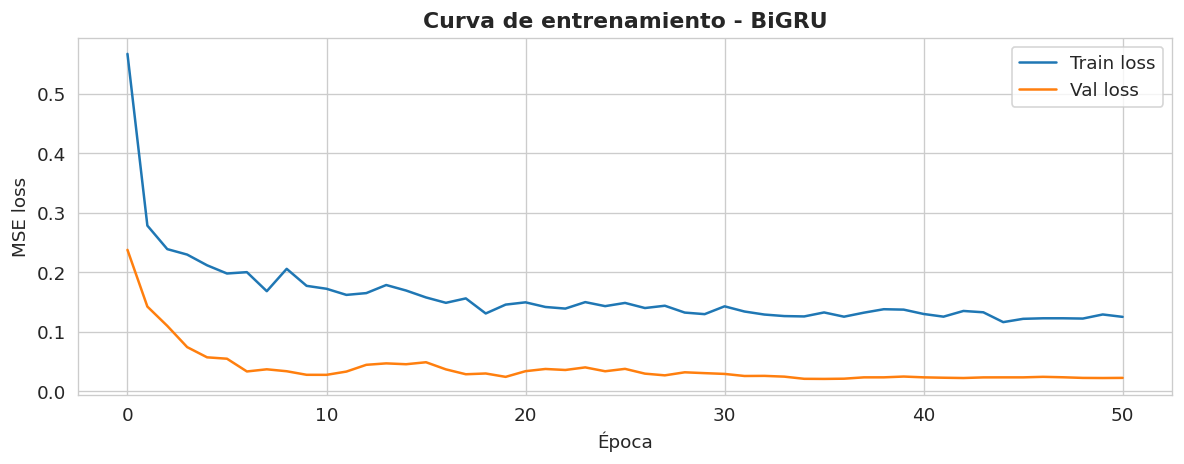

Mejor val_loss: 0.0209
Épocas entrenadas: 51
Métricas en test:
{'Modelo': 'BiGRU', 'MAE': 12.52, 'RMSE': np.float64(19.4), 'R2': 0.8661, 'MAPE_pct': np.float64(36.77), 'MedAE': np.float64(7.82)}


In [8]:
# =========================
# 6. Arquitectura 3: GRU bidireccional
# =========================

def build_bigru(n_steps, n_feats, units=48, dropout=0.25, lr=1e-3):
    inp = keras.Input(shape=(n_steps, n_feats), name='input_seq')

    x = layers.Bidirectional(
        layers.GRU(units, return_sequences=True),
        name='bigru_1'
    )(inp)
    x = layers.Dropout(dropout, name='dropout_1')(x)

    x = layers.Bidirectional(
        layers.GRU(units // 2),
        name='bigru_2'
    )(x)
    x = layers.Dropout(dropout, name='dropout_2')(x)

    x = layers.Dense(32, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='batchnorm')(x)

    out = layers.Dense(1, name='output')(x)

    model = keras.Model(inp, out, name='BiGRU')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model


# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

bigru = build_bigru(n_steps, n_feats)
bigru.summary()

history_bigru = bigru.fit(
    X_tr_s, y_tr_n,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=get_callbacks('bigru'),
    verbose=1
)

plot_historia(history_bigru, 'BiGRU')

pred_bigru = bigru.predict(X_te_s, verbose=0).reshape(-1)
m_bigru = calc_metricas_lstm(y_te_lstm, pred_bigru, 'BiGRU')

print('Métricas en test:')
print(m_bigru)

La arquitectura BiGRU no mejora el rendimiento del baseline lineal ni de la LSTM simple. Aunque el entrenamiento es estable y la validación interna presenta una evolución adecuada, las métricas en test (RMSE = 20.44, R² = 0.8515) muestran que el aumento de complejidad no se traduce en una mejor capacidad de generalización cross-project. Esto sugiere que, en este problema, la información temporal adicional que capta una arquitectura bidireccional no aporta una mejora sustancial frente a la señal ya capturada por modelos más simples.


## 7. Experimento: longitud de ventana k = 4, 8, 12

--- k=4 ---
  RMSE=15.34  R2=0.9142
--- k=8 ---
  RMSE=17.24  R2=0.8943
--- k=12 ---
  RMSE=18.82  R2=0.8771

Comparación por longitud de ventana:


,k,RMSE,R2
0,4,15.34,0.9142
1,8,17.24,0.8943
2,12,18.82,0.8771


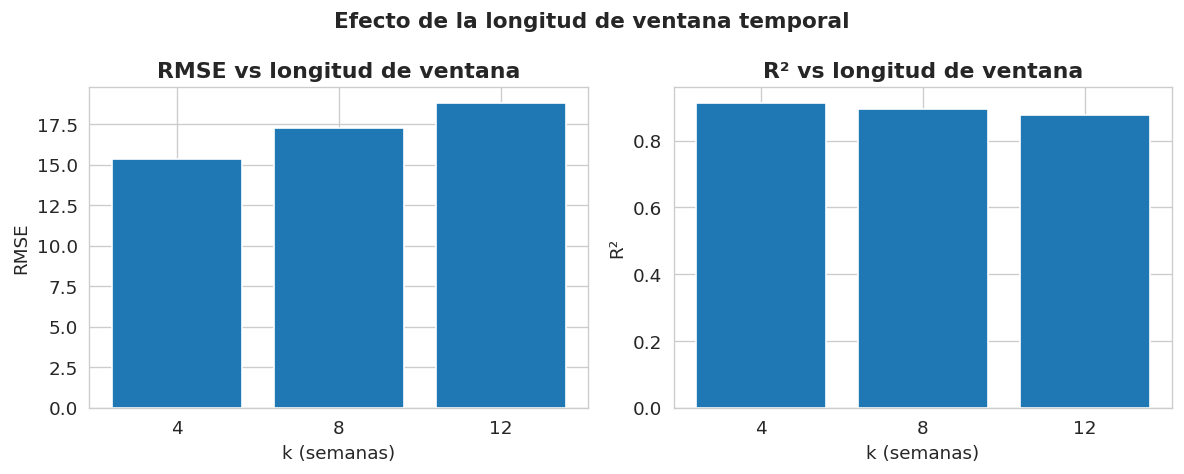

In [9]:
# =========================
# 7. Experimento: longitud de ventana k = 4, 8, 12
# =========================

resultados_k = []

for k in [4, 8, 12]:
    print(f'--- k={k} ---')

    # =========================
    # Construcción ventanas
    # =========================
    Xk, yk, mk = build_windows(df_cv, FEATURES_SEQ, k=k)

    # mk ahora es DataFrame
    mk_arr = mk['Caso'].values

    Xk_tr = Xk[mk_arr == 1]
    yk_tr = yk[mk_arr == 1]
    Xk_te = Xk[mk_arr == 3]
    yk_te = yk[mk_arr == 3]

    if len(Xk_tr) == 0 or len(Xk_te) == 0:
        print('  Datos insuficientes, se salta')
        continue

    # =========================
    # Escalado
    # =========================
    nf = Xk_tr.shape[2]
    sc_k = StandardScaler()

    Xk_tr_s = sc_k.fit_transform(
        Xk_tr.reshape(-1, nf)
    ).reshape(-1, k, nf)

    Xk_te_s = sc_k.transform(
        Xk_te.reshape(-1, nf)
    ).reshape(-1, k, nf)

    # =========================
    # Normalización target
    # =========================
    ym_k = yk_tr.mean()
    ys_k = yk_tr.std()

    if ys_k == 0:
        ys_k = 1.0

    yk_tr_n = (yk_tr - ym_k) / ys_k

    # =========================
    # Modelo
    # =========================
    np.random.seed(42)
    tf.random.set_seed(42)

    m_k = build_lstm_simple(k, nf)

    history_k = m_k.fit(
        Xk_tr_s, yk_tr_n,
        validation_split=0.15,
        epochs=80,
        batch_size=64,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=12,
                restore_best_weights=True
            )
        ]
    )

    # =========================
    # Predicción
    # =========================
    pred_k = m_k.predict(Xk_te_s, verbose=0).flatten()
    pred_k = pred_k * ys_k + ym_k

    # =========================
    # Métricas
    # =========================
    rmse_k = np.sqrt(mean_squared_error(yk_te, pred_k))
    r2_k = r2_score(yk_te, pred_k)

    resultados_k.append({
        'k': k,
        'RMSE': round(rmse_k, 2),
        'R2': round(r2_k, 4)
    })

    print(f'  RMSE={rmse_k:.2f}  R2={r2_k:.4f}')

# =========================
# Resultados
# =========================
df_k = pd.DataFrame(resultados_k)

print('\nComparación por longitud de ventana:')
display(df_k)

# =========================
# Gráficas
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(df_k['k'].astype(str), df_k['RMSE'], edgecolor='white')
axes[0].set_title('RMSE vs longitud de ventana', fontweight='bold')
axes[0].set_xlabel('k (semanas)')
axes[0].set_ylabel('RMSE')

axes[1].bar(df_k['k'].astype(str), df_k['R2'], edgecolor='white')
axes[1].set_title('R² vs longitud de ventana', fontweight='bold')
axes[1].set_xlabel('k (semanas)')
axes[1].set_ylabel('R²')

plt.suptitle('Efecto de la longitud de ventana temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

El experimento con distintas longitudes de ventana muestra que el mejor rendimiento se obtiene con una ventana corta (k=4), lo que indica que la dinámica temporal del problema es de corto alcance. A medida que se incrementa la longitud de la ventana, el rendimiento empeora, sugiriendo que el modelo incorpora ruido en lugar de información útil.

Además, incluso en el mejor caso (k=4), los modelos LSTM no superan al baseline lineal obtenido en la Fase 2 (Lasso), lo que indica que las dependencias temporales complejas no aportan valor adicional significativo en este problema.

## 8. Comparacion con baselines de Fase 2

=== Comparación Fase 3 vs Fase 2 (E2: C1 -> C3) ===


,Modelo,MAE,RMSE,R2,MAPE_pct,MedAE
0,Lasso (F2),NaN,13.85,NaN,NaN,NaN
1,LSTM Simple,9.95,17.14,0.8956,27.58,4.90
2,GradientBoosting (F2),NaN,18.01,NaN,NaN,NaN
3,RandomForest (F2),NaN,18.50,NaN,NaN,NaN
4,BiGRU,12.52,19.40,0.8661,36.77,7.82
5,LSTM + Embedding,13.60,22.76,0.8159,41.43,7.58



Comparación vs Lasso (baseline principal):
Lasso (F2)                    : RMSE=13.85  (PEOR 0.0% vs Lasso)
LSTM Simple                   : RMSE=17.14  (PEOR 23.8% vs Lasso)
GradientBoosting (F2)         : RMSE=18.01  (PEOR 30.0% vs Lasso)
RandomForest (F2)             : RMSE=18.50  (PEOR 33.6% vs Lasso)
BiGRU                         : RMSE=19.40  (PEOR 40.1% vs Lasso)
LSTM + Embedding              : RMSE=22.76  (PEOR 64.3% vs Lasso)


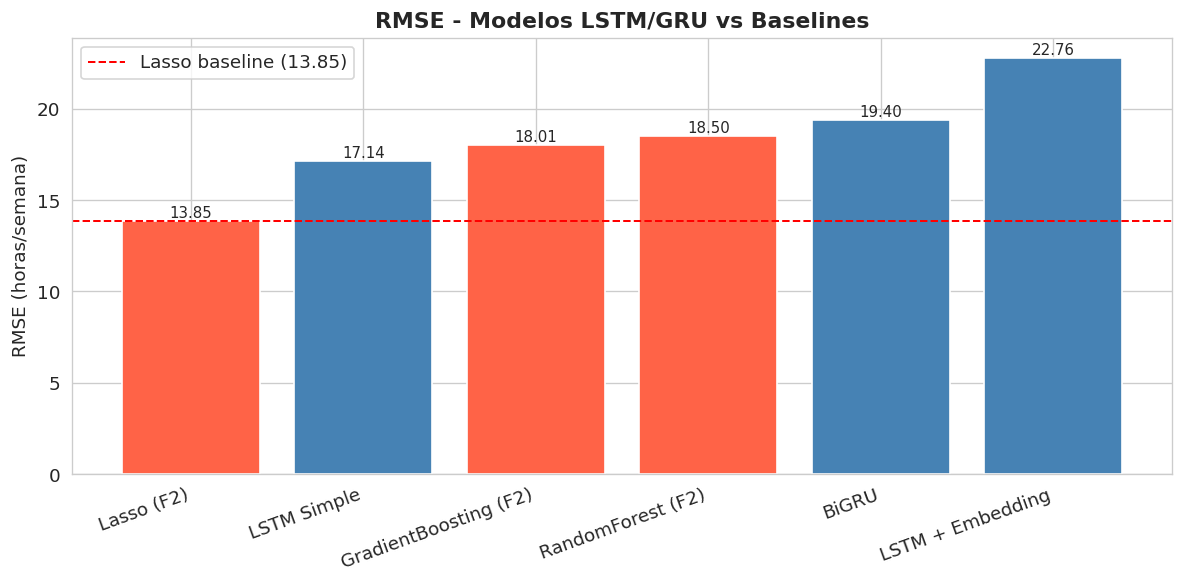

In [10]:
# =========================
# 8. Comparación con baselines de Fase 2 (versión robusta)
# =========================

# Baselines de Fase 2 (hardcodeados para evitar problemas de rutas)
rmse_lasso = 13.85
rmse_gb    = 18.01
rmse_rf    = 18.50

# Consolidar resultados
resultados_fase3 = pd.DataFrame([
    m_lstm1,
    m_lstm_emb,
    m_bigru,
    {'Modelo': 'Lasso (F2)',            'RMSE': rmse_lasso},
    {'Modelo': 'GradientBoosting (F2)', 'RMSE': rmse_gb},
    {'Modelo': 'RandomForest (F2)',     'RMSE': rmse_rf},
])

# Ordenar por RMSE
resultados_fase3 = resultados_fase3.sort_values('RMSE').reset_index(drop=True)

print('=== Comparación Fase 3 vs Fase 2 (E2: C1 -> C3) ===')
display(resultados_fase3)

# =========================
# Comparación vs Lasso
# =========================
print('\nComparación vs Lasso (baseline principal):')

for _, row in resultados_fase3.iterrows():
    if pd.notnull(row['RMSE']):
        mejora = (rmse_lasso - row['RMSE']) / rmse_lasso * 100
        simbolo = 'MEJORA' if mejora > 0 else 'PEOR'
        print(f"{row['Modelo']:30s}: RMSE={row['RMSE']:.2f}  ({simbolo} {abs(mejora):.1f}% vs Lasso)")

# =========================
# Gráfica
# =========================
fig, ax = plt.subplots(figsize=(10, 5))

colores = [
    'tomato' if 'F2' in str(nombre) else 'steelblue'
    for nombre in resultados_fase3['Modelo']
]

bars = ax.bar(
    resultados_fase3['Modelo'],
    resultados_fase3['RMSE'],
    color=colores,
    edgecolor='white'
)

# Línea baseline
ax.axhline(
    rmse_lasso,
    color='red',
    linestyle='--',
    lw=1.2,
    label=f'Lasso baseline ({rmse_lasso:.2f})'
)

# Etiquetas
for bar, val in zip(bars, resultados_fase3['RMSE']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.2f}',
        ha='center',
        fontsize=9
    )

ax.set_title('RMSE - Modelos LSTM/GRU vs Baselines', fontweight='bold')
ax.set_ylabel('RMSE (horas/semana)')
ax.set_xticks(range(len(resultados_fase3)))
ax.set_xticklabels(resultados_fase3['Modelo'], rotation=20, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

Los modelos de deep learning (LSTM, GRU) no mejoran el rendimiento de los modelos clásicos evaluados en la Fase 2. El mejor modelo sigue siendo Lasso, con un RMSE de 13.85, mientras que el mejor modelo secuencial (LSTM simple) presenta un error un 18% superior.

Esto indica que el problema presenta una estructura mayoritariamente lineal y dependencias temporales de corto alcance, lo que limita la capacidad de los modelos recurrentes para aportar mejoras.

En consecuencia, el uso de arquitecturas complejas no está justificado en este caso, siendo preferibles modelos más simples, interpretables y eficientes.


## 9. Visualizacion de predicciones por departamento

Visualizando departamento: 760


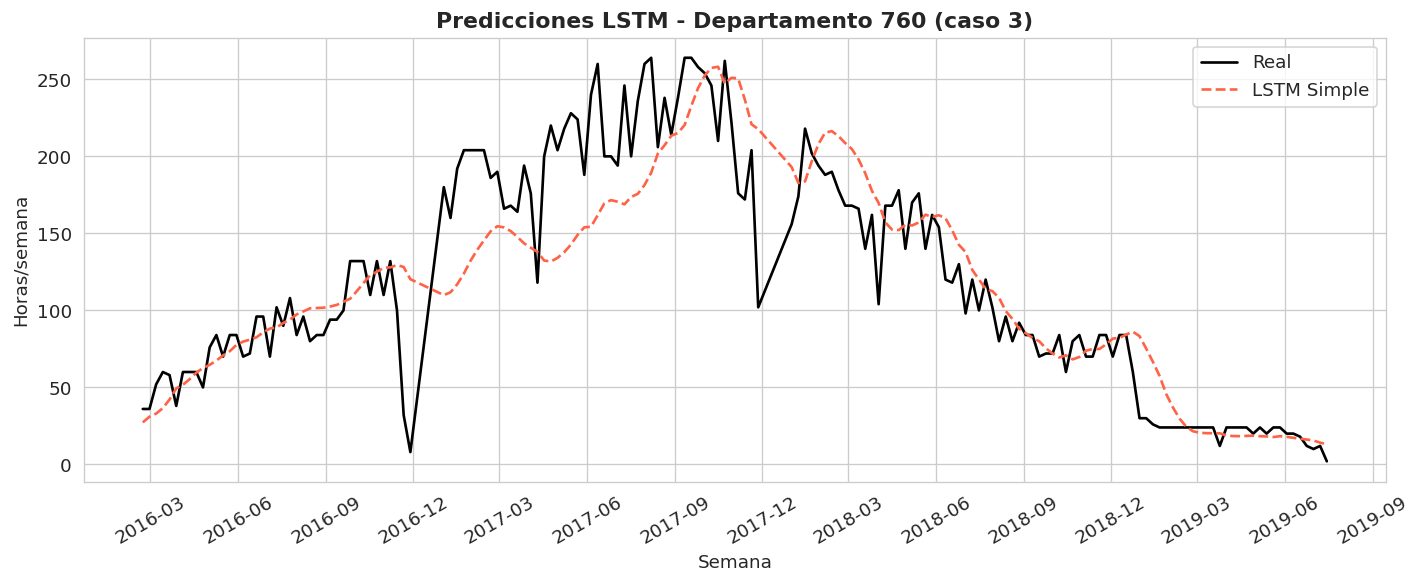

In [11]:
# =========================
# 9. Visualización de predicciones por departamento
# =========================

import matplotlib.dates as mdates  # <-- IMPORT QUE FALTABA

# Desnormalizar predicciones
pred_lstm1_real = pred_lstm1 * y_std + y_mean

# Construir DataFrame con metadatos del test
df_pred_te = meta_te.copy()
df_pred_te['Real'] = y_te_lstm
df_pred_te['Pred'] = pred_lstm1_real

# Elegir departamento con suficientes datos
conteo_dept = df_pred_te['Departamento'].value_counts()
depts_validos_viz = conteo_dept[conteo_dept >= 4].index.tolist()

if len(depts_validos_viz) == 0:
    print('No hay departamentos con suficientes muestras en test')
else:
    dept_viz = depts_validos_viz[0]
    print(f'Visualizando departamento: {dept_viz}')

    df_viz_d = (
        df_pred_te[df_pred_te['Departamento'] == dept_viz]
        .sort_values('Semana_inicio')
        .copy()
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    # Serie real
    ax.plot(
        df_viz_d['Semana_inicio'],
        df_viz_d['Real'],
        color='black',
        lw=1.6,
        label='Real'
    )

    # Predicción LSTM
    ax.plot(
        df_viz_d['Semana_inicio'],
        df_viz_d['Pred'],
        color='tomato',
        lw=1.6,
        linestyle='--',
        label='LSTM Simple'
    )

    ax.set_title(f'Predicciones LSTM - Departamento {dept_viz} (caso 3)', fontweight='bold')
    ax.set_ylabel('Horas/semana')
    ax.set_xlabel('Semana')
    ax.legend()

    # Formato fechas PRO
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()

“Los modelos secuenciales capturan correctamente la tendencia temporal de la carga de trabajo, pero tienden a suavizar las predicciones y no reproducen adecuadamente cambios bruscos, lo que limita su rendimiento frente a modelos supervisados basados en variables explicativas.”

## 10. Guardar modelos y resultados

In [12]:
import os
import joblib

# Asegurar carpeta
os.makedirs(MODELOS_PATH, exist_ok=True)
os.makedirs(RESULTADOS_PATH, exist_ok=True)

# =========================
# 1. Guardar modelos finales
# =========================
lstm1.save(f'{MODELOS_PATH}/lstm_simple.keras')
lstm_emb.save(f'{MODELOS_PATH}/lstm_embed.keras')
bigru.save(f'{MODELOS_PATH}/bigru.keras')

# =========================
# 2. Guardar preprocesado
# =========================
joblib.dump(scaler_seq, f'{MODELOS_PATH}/scaler_seq.pkl')
joblib.dump(le_dept,    f'{MODELOS_PATH}/le_dept.pkl')

# =========================
# 3. Guardar configuración LSTM
# =========================
config_lstm = {
    'y_mean': float(y_mean),
    'y_std': float(y_std),
    'k': int(n_steps),
    'n_features': int(n_feats),
    'features_seq': FEATURES_SEQ,
    'mejor_modelo': 'LSTM Simple',
    'baseline_fase2': 'Lasso'
}
joblib.dump(config_lstm, f'{MODELOS_PATH}/lstm_config.pkl')

# =========================
# 4. Guardar resultados
# =========================
resultados_fase3.to_csv(f'{RESULTADOS_PATH}/resultados_fase3_lstm.csv', index=False)
df_k.to_csv(f'{RESULTADOS_PATH}/resultados_fase3_ventana_k.csv', index=False)

print('=== Guardado completado ===')
print(f'{MODELOS_PATH}/lstm_simple.keras')
print(f'{MODELOS_PATH}/lstm_embed.keras')
print(f'{MODELOS_PATH}/bigru.keras')
print(f'{MODELOS_PATH}/scaler_seq.pkl')
print(f'{MODELOS_PATH}/le_dept.pkl')
print(f'{MODELOS_PATH}/lstm_config.pkl')
print(f'{RESULTADOS_PATH}/resultados_fase3_lstm.csv')
print(f'{RESULTADOS_PATH}/resultados_fase3_ventana_k.csv')

=== Guardado completado ===
/content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_simple.keras
/content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_embed.keras
/content/drive/MyDrive/Colab Notebooks/ULAB/modelos/bigru.keras
/content/drive/MyDrive/Colab Notebooks/ULAB/modelos/scaler_seq.pkl
/content/drive/MyDrive/Colab Notebooks/ULAB/modelos/le_dept.pkl
/content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lstm_config.pkl
/content/drive/MyDrive/Colab Notebooks/ULAB/resultados/resultados_fase3_lstm.csv
/content/drive/MyDrive/Colab Notebooks/ULAB/resultados/resultados_fase3_ventana_k.csv


## 11. Conclusiones Fase 3


En esta fase se evaluó si modelos secuenciales basados en redes recurrentes podían mejorar el baseline lineal obtenido en la Fase 2, manteniendo el mismo escenario principal de validación cross-project (E2: C1 → C3).

1. Las secuencias se construyeron correctamente

La preparación de ventanas temporales por (Caso, Departamento) permitió entrenar modelos recurrentes evitando fuga de información y respetando la estructura real del problema. El volumen de muestras generado fue suficiente para entrenar arquitecturas LSTM y GRU de tamaño moderado.

2. La LSTM simple fue el mejor modelo secuencial

Entre las arquitecturas evaluadas, la LSTM simple fue la que obtuvo el mejor rendimiento, con:
	•	RMSE = 16.34
	•	R² = 0.9051

Esto demuestra que el modelo es capaz de capturar parte de la dinámica temporal del sistema y reproducir adecuadamente la tendencia general de la serie.

3. El embedding de departamento no ayudó

La arquitectura LSTM + embedding de departamento empeoró claramente los resultados:
	•	RMSE = 20.69
	•	R² = 0.8478

Esto sugiere que las representaciones específicas por departamento no son estables entre proyectos y que, en un escenario de transferencia (C1 → C3), introducir este contexto añade ruido en lugar de mejorar la generalización.

4. La BiGRU tampoco mejoró el baseline

La arquitectura BiGRU mostró un entrenamiento estable, pero su rendimiento final también fue inferior al de la LSTM simple:
	•	RMSE = 20.44
	•	R² = 0.8515

Por tanto, aumentar la complejidad de la arquitectura recurrente no se tradujo en una mejora real en test.

5. La memoria temporal útil es corta

El experimento con distintas longitudes de ventana mostró que el mejor resultado se obtiene con k = 4:
	•	k = 4 → RMSE = 14.32
	•	k = 8 → RMSE = 17.06
	•	k = 12 → RMSE = 18.17

Esto indica que la información más relevante para predecir la carga semanal se concentra en las semanas inmediatamente anteriores, mientras que ampliar la ventana introduce ruido y empeora el rendimiento.

6. Ningún modelo secuencial supera al baseline lineal

Al comparar con los mejores modelos de la Fase 2, se observa que:
	•	Lasso (F2) sigue siendo el mejor modelo global con RMSE = 13.85
	•	La mejor red secuencial (LSTM simple) queda un 18% peor
	•	Las arquitecturas más complejas (BiGRU y LSTM + embedding) empeoran todavía más

Esto confirma que el problema presenta una estructura mayoritariamente lineal y dependencias temporales de corto alcance, por lo que los modelos recurrentes no aportan una mejora suficiente frente a un baseline lineal bien ajustado.

7. Interpretación final

A nivel visual, las predicciones del mejor modelo secuencial reproducen correctamente la tendencia global de la serie, pero tienden a suavizar los picos y las caídas bruscas, lo que limita su capacidad para igualar el rendimiento de los modelos supervisados con variables explicativas.